# Dashboard de Calidad de Datos (Data Quality)

Este notebook amplía el análisis de `data_quality.py` para proporcionar visualizaciones de diagnóstico sobre la integridad, validez y consistencia del dataset unificado de clima. 

**Nota:** El dataset ahora utiliza pronósticos de alta resolución por punto (estación) en lugar de pronósticos por zona.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

INPUT_PARQUET = "clima_unificado.parquet"

## 0. Carga de Datos

In [3]:
if os.path.exists(INPUT_PARQUET):
    df = pd.read_parquet(INPUT_PARQUET)
    print(f"Dataset cargado: {len(df)} filas y {len(df.columns)} columnas.")
    display(df.head())
else:
    print(f"Error: No se encontró {INPUT_PARQUET}. Ejecuta unify_data.py primero.")

Dataset cargado: 116854 filas y 26 columnas.


,station_id,obs_timestamp,temp_real,dew_real,hum_real,wind_speed_real,wind_gust_real,wind_dir_real,press_real,sea_level_press_real,...,fcst_start,fcst_end,is_daytime_fcst,temp_fcst,dew_fcst,hum_fcst,wind_speed_fcst,wind_dir_fcst,precip_prob_fcst,short_fcst
0,KXBP,2026-04-16 04:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-04-16 04:00:00+00:00,2026-04-16 05:00:00+00:00,False,20.000000,18.333333,90.0,16.09340,S,5.0,Partly Cloudy
1,KPVW,2026-04-16 04:10:00+00:00,11.9,-11.6,18.157693,0.00,NaN,0.0,101360.0,NaN,...,2026-04-16 04:00:00+00:00,2026-04-16 05:00:00+00:00,False,15.000000,-7.222222,21.0,8.04670,WSW,0.0,Clear
2,KCQB,2026-04-16 04:10:00+00:00,19.0,17.4,90.445091,20.52,NaN,190.0,101080.0,NaN,...,2026-04-16 04:00:00+00:00,2026-04-16 05:00:00+00:00,False,18.888889,17.222222,90.0,14.48406,S,11.0,Partly Cloudy
3,KVYS,2026-04-16 04:10:00+00:00,15.0,14.1,94.355349,20.52,NaN,30.0,100950.0,NaN,...,2026-04-16 04:00:00+00:00,2026-04-16 05:00:00+00:00,False,18.888889,16.111111,85.0,24.14010,SSW,76.0,Showers And Thunderstorms
4,KOJA,2026-04-16 04:10:00+00:00,18.9,15.9,82.740233,12.96,NaN,210.0,101080.0,NaN,...,2026-04-16 04:00:00+00:00,2026-04-16 05:00:00+00:00,False,17.777778,8.333333,54.0,11.26538,S,3.0,Mostly Clear


## 1. INTEGRIDAD (Completitud)

¿Qué tan completo es nuestro dataset? Visualizamos los valores nulos por columna.

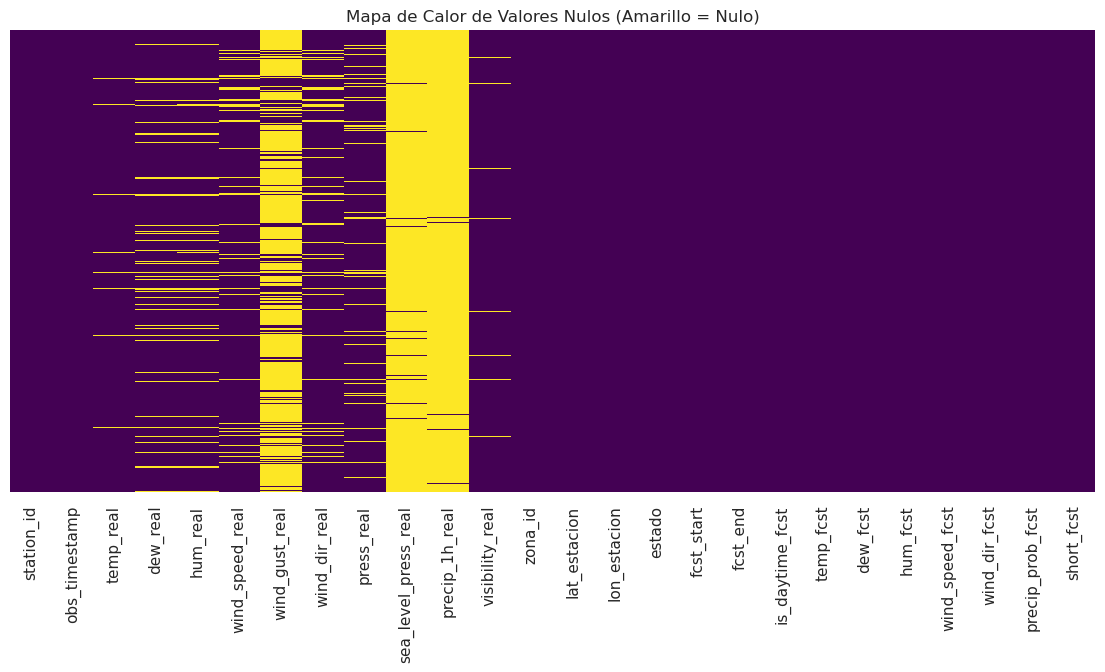

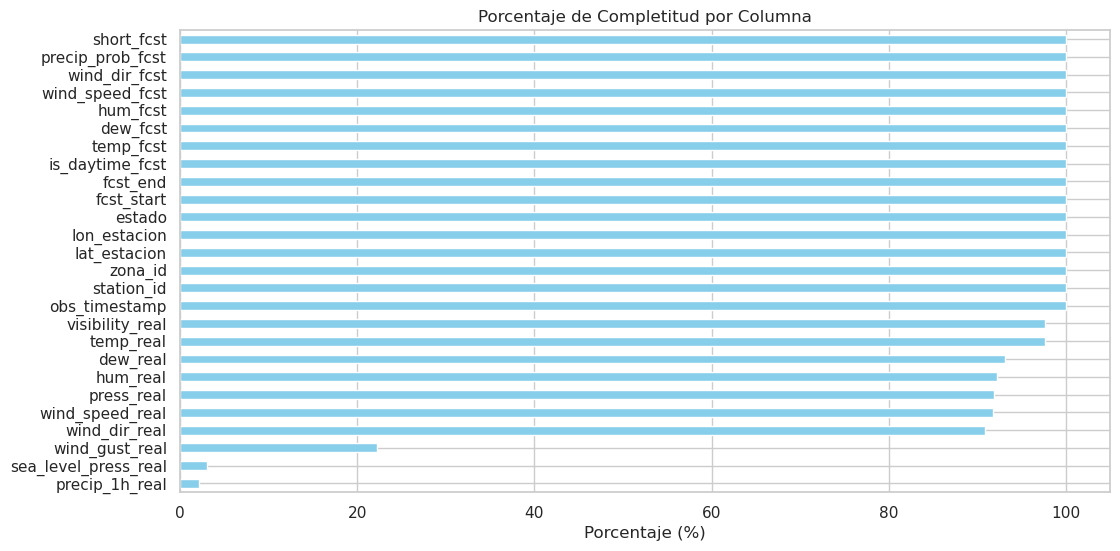

In [4]:
# Mapa de calor de nulos
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Valores Nulos (Amarillo = Nulo)')
plt.show()

# Porcentaje de completitud
integrity = (df.notnull().sum() / len(df) * 100).sort_values()
integrity.plot(kind='barh', color='skyblue')
plt.title('Porcentaje de Completitud por Columna')
plt.xlabel('Porcentaje (%)')
plt.show()

### Observaciones:

1. windGust (Ráfagas)
   * Interpretación: Si el campo es null, es altamente probable que el viento fuera estable. 

2. seaLevelPressure (Presión al Nivel del Mar)
   * Disponibilidad: Muchas estaciones solo reportan la presión de la estación (barometricPressure).

3. precipitationLastHour (Precipitación)
   * Interpretación: El null suele significar ausencia de lluvia o de sensor de precipitación en esa estación específica.

## 2. UNICIDAD

Buscamos duplicados basados en la llave natural: `station_id` + `obs_timestamp`.

In [5]:
duplicates = df.duplicated(subset=['station_id', 'obs_timestamp']).sum()
print(f"Filas duplicadas: {duplicates}")
print(f"Índice de Unicidad: {(1 - (duplicates / len(df))) * 100:.2f}%")

if duplicates > 0:
    print("Muestra de duplicados:")
    display(df[df.duplicated(subset=['station_id', 'obs_timestamp'], keep=False)].sort_values(by=['station_id', 'obs_timestamp']).head())

Filas duplicadas: 51
Índice de Unicidad: 99.96%
Muestra de duplicados:


,station_id,obs_timestamp,temp_real,dew_real,hum_real,wind_speed_real,wind_gust_real,wind_dir_real,press_real,sea_level_press_real,...,fcst_start,fcst_end,is_daytime_fcst,temp_fcst,dew_fcst,hum_fcst,wind_speed_fcst,wind_dir_fcst,precip_prob_fcst,short_fcst
24577,K1D8,2026-04-19 01:35:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2026-04-19 01:00:00+00:00,2026-04-19 02:00:00+00:00,False,7.222222,-6.666667,36.0,27.35878,WNW,6.0,Partly Cloudy
24754,K1D8,2026-04-19 01:35:00+00:00,4.0,-8.0,41.259996,11.124,NaN,270.0,101727.12,NaN,...,2026-04-19 01:00:00+00:00,2026-04-19 02:00:00+00:00,False,7.222222,-6.666667,36.0,27.35878,WNW,6.0,Partly Cloudy
42904,K1D8,2026-04-21 01:35:00+00:00,NaN,2.0,NaN,9.252,NaN,160.0,100778.93,NaN,...,2026-04-21 01:00:00+00:00,2026-04-21 02:00:00+00:00,False,20.555556,2.777778,31.0,4.82802,S,0.0,Partly Cloudy
42990,K1D8,2026-04-21 01:35:00+00:00,18.0,2.0,34.250230,9.252,NaN,160.0,100778.93,NaN,...,2026-04-21 01:00:00+00:00,2026-04-21 02:00:00+00:00,False,20.555556,2.777778,31.0,4.82802,S,0.0,Partly Cloudy
68859,K1D8,2026-04-24 01:35:00+00:00,8.0,1.0,61.296851,22.212,NaN,330.0,100643.47,NaN,...,2026-04-24 01:00:00+00:00,2026-04-24 02:00:00+00:00,False,9.444444,0.555556,54.0,35.40548,WNW,0.0,Partly Cloudy


## 3. VALIDEZ (Outliers y Reglas de Negocio)

Validamos que las variables físicas estén dentro de rangos coherentes.

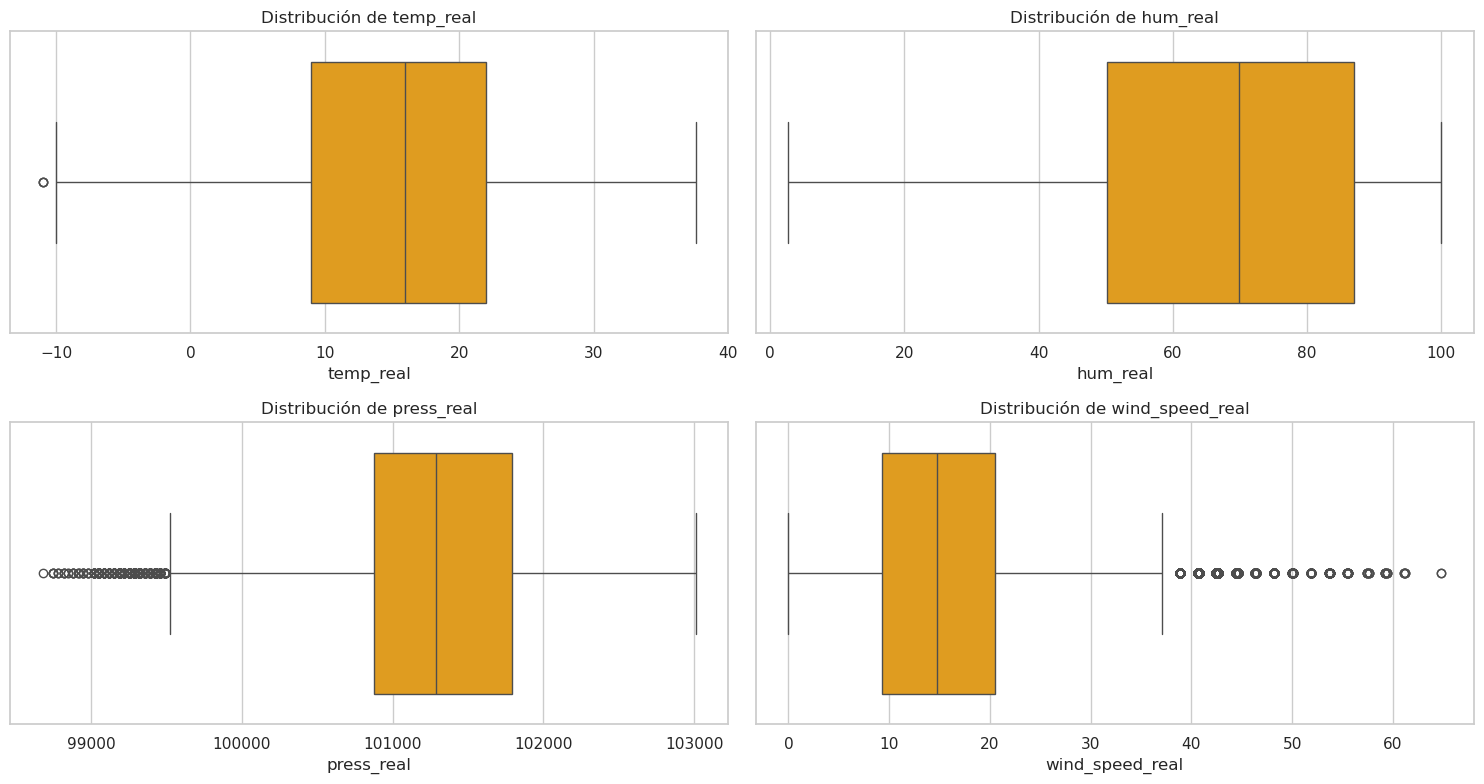

In [6]:
cols_to_check = ['temp_real', 'hum_real', 'press_real', 'wind_speed_real']

plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_check, 1):
    if col in df.columns:
        plt.subplot(2, 2, i)
        sns.boxplot(x=df[col], color='orange')
        plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

## 4. OPORTUNIDAD (Línea de Tiempo)

Analizamos la cobertura temporal del dataset.

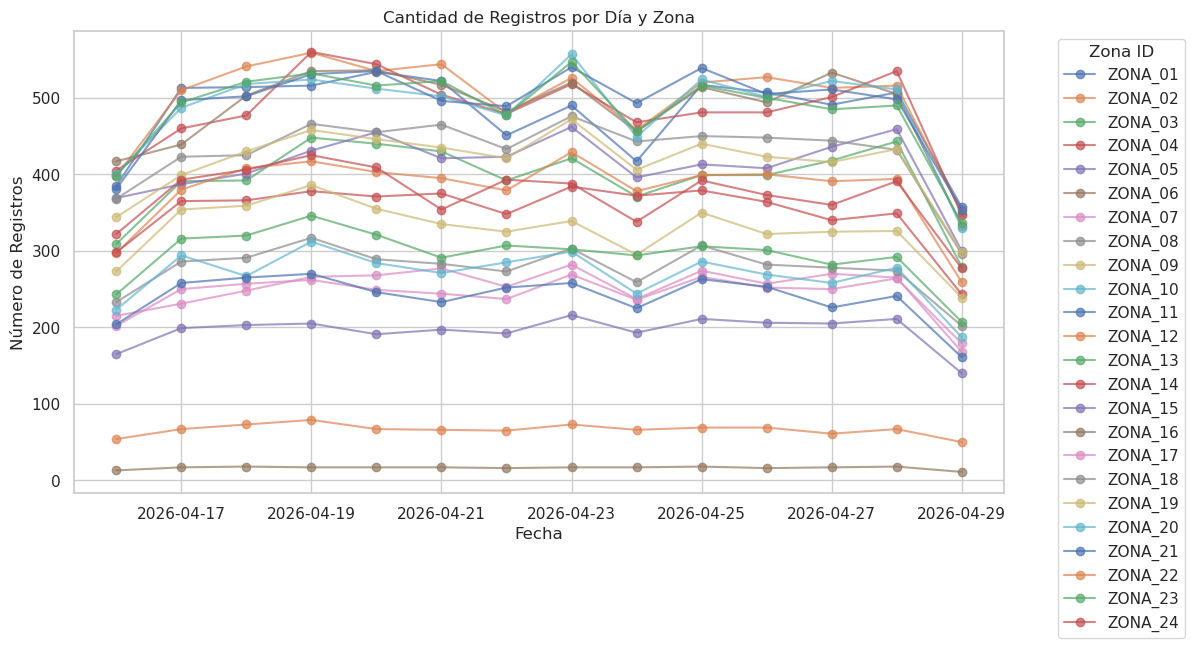

In [7]:
df['fecha'] = df['obs_timestamp'].dt.date
timeline = df.groupby(['fecha', 'zona_id']).size().unstack(fill_value=0)

timeline.plot(marker='o', alpha=0.7)
plt.title('Cantidad de Registros por Día y Zona')
plt.ylabel('Número de Registros')
plt.xlabel('Fecha')
plt.legend(title='Zona ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. CONSISTENCIA (Real vs Pronóstico)

Comparamos la temperatura real contra el forecast de alta resolución.

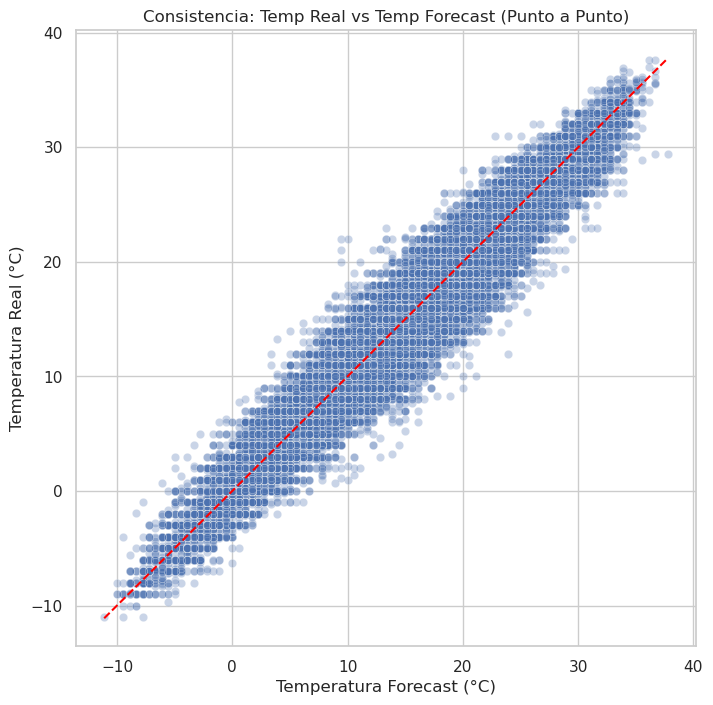

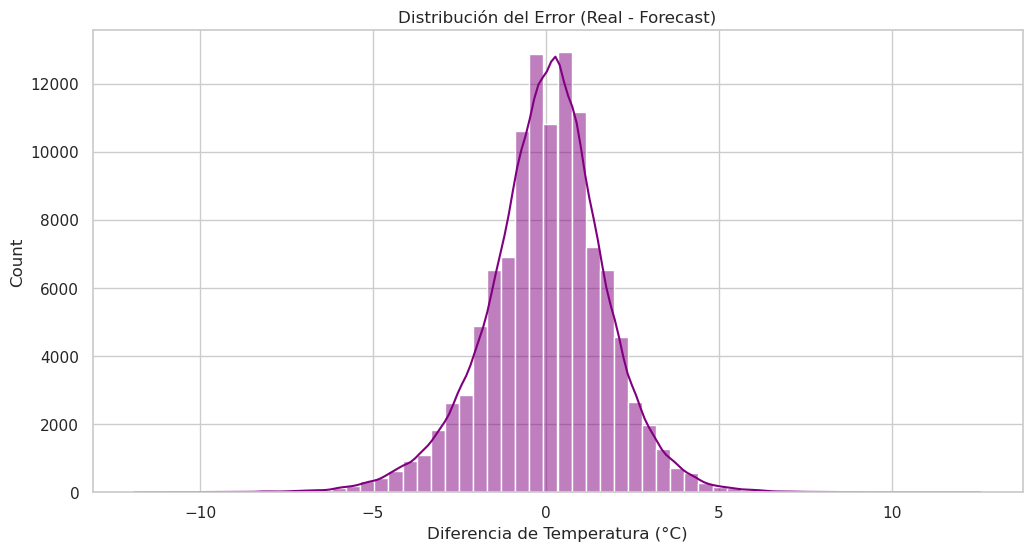

In [11]:
if 'temp_real' in df.columns and 'temp_fcst' in df.columns:
    plt.figure(figsize=(8, 8))
    aligned = df.dropna(subset=['temp_real', 'temp_fcst'])
    
    sns.scatterplot(data=aligned, x='temp_fcst', y='temp_real', alpha=0.3)
    limit_min = min(aligned['temp_real'].min(), aligned['temp_fcst'].min())
    limit_max = max(aligned['temp_real'].max(), aligned['temp_fcst'].max())
    plt.plot([limit_min, limit_max], [limit_min, limit_max], color='red', linestyle='--')

    plt.title('Consistencia: Temp Real vs Temp Forecast (Punto a Punto)')
    plt.xlabel('Temperatura Forecast (°C)')
    plt.ylabel('Temperatura Real (°C)')
    plt.show()
    
    # Distribución del Error
    error_dist = aligned['temp_real'] - aligned['temp_fcst']
    sns.histplot(error_dist, kde=True, color='purple', bins=60)
    plt.title('Distribución del Error (Real - Forecast)')
    plt.xlabel('Diferencia de Temperatura (°C)')
    plt.show()

### Observaciones

- **Unificación de Unidades:** Los pronósticos se convierten de Fahrenheit a Celsius durante la unificación.
- **Alta Resolución:** Al usar pronósticos específicos por estación (punto a punto), la consistencia debería ser superior a la versión anterior basada en zonas, ya que se eliminan variaciones microclimáticas no capturadas por el promedio de zona.

## 6. IDONEIDAD (Estaciones y Cobertura)

¿Cuántos datos aporta cada estación?

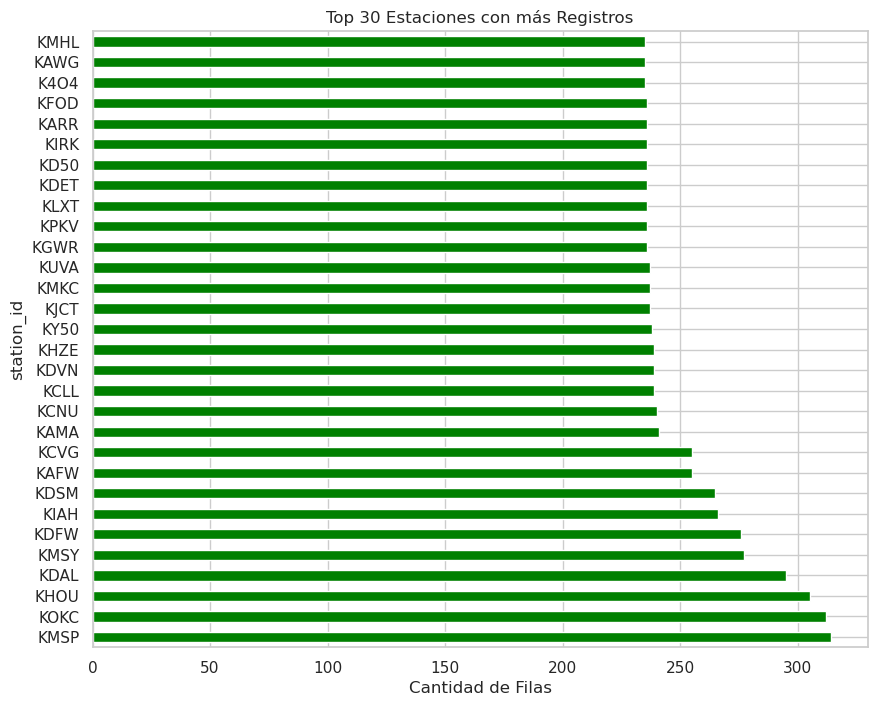

In [9]:
plt.figure(figsize=(10, 8))
df['station_id'].value_counts().head(30).plot(kind='barh', color='green')
plt.title('Top 30 Estaciones con más Registros')
plt.xlabel('Cantidad de Filas')
plt.show()

## 7. ANÁLISIS DE GRANULARIDAD (Nueva Resolución)

Verificamos si estaciones dentro de la misma zona tienen pronósticos distintos (lo cual confirma la alta resolución).

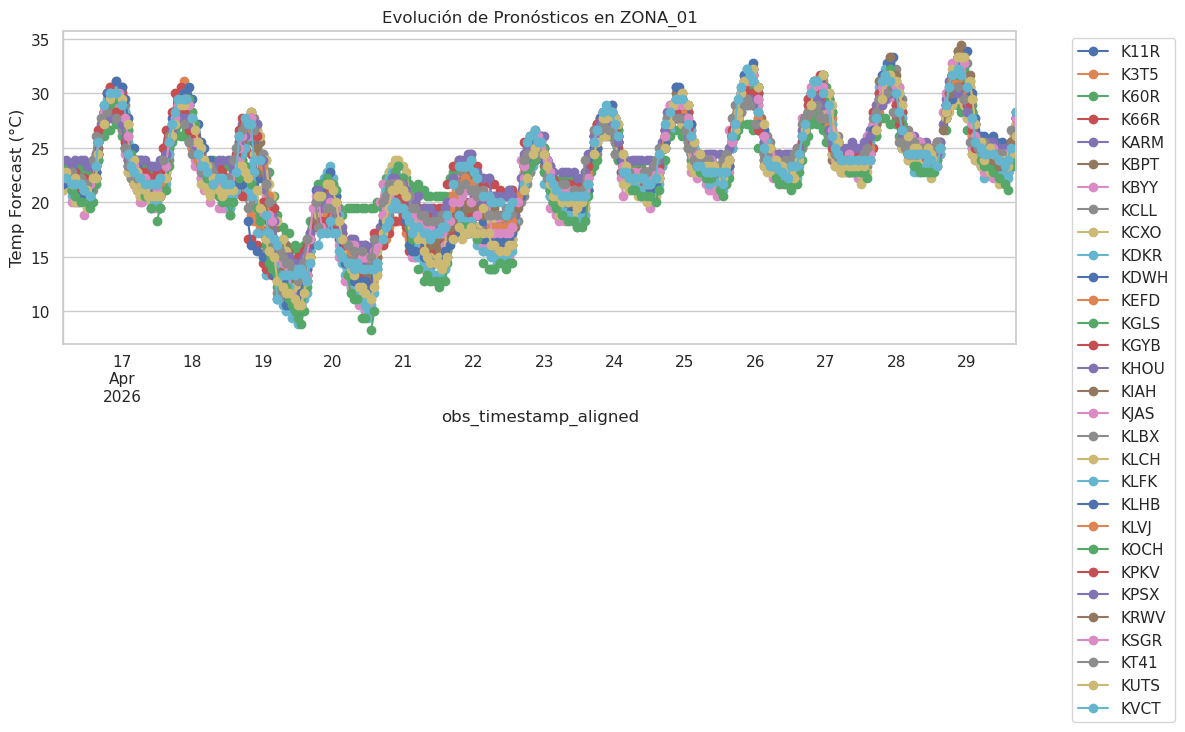

Desviación estándar promedio entre estaciones de la misma zona: 1.1702 °C
✅ Confirmado: Las estaciones tienen pronósticos específicos (Alta Resolución).


In [10]:
if 'temp_fcst' in df.columns:
    # Buscamos zonas que tengan más de una estación en el dataset
    station_counts = df.groupby('zona_id')['station_id'].nunique()
    multi_station_zones = station_counts[station_counts > 1].index.tolist()
    
    if len(multi_station_zones) > 0:
        # Tomamos la zona con más estaciones para una mejor visualización
        sample_zona = station_counts.loc[multi_station_zones].idxmax()
        sample_df = df[df['zona_id'] == sample_zona].copy()
        
        # Redondeamos a la hora para alinear las observaciones de distintas estaciones en el batch
        sample_df['obs_timestamp_aligned'] = sample_df['obs_timestamp'].dt.round('h')
        
        # Pivotamos para ver temp_fcst por estación
        granularity = sample_df.pivot_table(
            index='obs_timestamp_aligned', 
            columns='station_id', 
            values='temp_fcst',
            aggfunc='first'
        )
        
        if granularity.shape[1] > 1:
            if len(granularity) == 1:
                # Si solo hay un lote de tiempo, usamos barras
                granularity.T.plot(kind='bar', title=f'Comparación de Pronósticos en {sample_zona} (Instante Único)')
                plt.xticks(rotation=45)
            else:
                # Si hay evolución temporal, usamos líneas con marcadores
                granularity.plot(marker='o', title=f'Evolución de Pronósticos en {sample_zona}')
            
            plt.ylabel('Temp Forecast (°C)')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
            
            # Calculamos la desviación estándar promedio entre estaciones para validar la resolución
            std_devs = granularity.std(axis=1)
            mean_std = std_devs.mean()
            print(f"Desviación estándar promedio entre estaciones de la misma zona: {mean_std:.4f} °C")
            if mean_std > 0.001:
                print("✅ Confirmado: Las estaciones tienen pronósticos específicos (Alta Resolución).")
            else:
                print("⚠️ Aviso: Las estaciones comparten el mismo pronóstico (Posibles datos legados).")
        else:
            print(f"La zona {sample_zona} no tiene suficientes estaciones alineadas temporalmente.")
    else:
        print("No se encontraron zonas con múltiples estaciones para el análisis de granularidad.")